**Exercise**

Use famous iris flower dataset from sklearn.datasets to predict flower species using random forest classifier.

- Measure prediction score using default n_estimators (10)
- Now fine tune your model by changing number of trees in your classifer and tell me what best score you can get using how many trees

In [3]:
import pandas as pd
from sklearn.datasets import load_iris
iris=load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [47]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
target=pd.DataFrame(iris.target,columns=['target'])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [40]:
from sklearn.ensemble import RandomForestClassifier
model_10=RandomForestClassifier(n_estimators=10)
model_20=RandomForestClassifier(n_estimators=20)
model_30=RandomForestClassifier(n_estimators=30)

In [54]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df,target,test_size=0.3)

In [55]:
model_10.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(n_estimators=10)

In [56]:
model_20.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(n_estimators=20)

In [57]:
model_30.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(n_estimators=30)

### Comparing Scores to Find the Best Model

Let's compare the scores obtained from models with different `n_estimators` to identify the best performing model.

In [58]:
score_10 = model_10.score(x_test, y_test)
score_20 = model_20.score(x_test, y_test)
score_30 = model_30.score(x_test, y_test)

print(f"Score with n_estimators=10: {score_10:.4f}")
print(f"Score with n_estimators=20: {score_20:.4f}")
print(f"Score with n_estimators=30: {score_30:.4f}")

best_score = max(score_10, score_20, score_30)

if best_score == score_10:
    best_n_estimators = 10
elif best_score == score_20:
    best_n_estimators = 20
else:
    best_n_estimators = 30

print(f"\nThe best score achieved is {best_score:.4f} with n_estimators = {best_n_estimators}.")

Score with n_estimators=10: 0.9556
Score with n_estimators=20: 0.9556
Score with n_estimators=30: 0.9556

The best score achieved is 0.9556 with n_estimators = 10.


In [59]:
predict_10=model_10.predict(x_test)

In [60]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,predict_10)
cm

array([[18,  0,  0],
       [ 0, 17,  0],
       [ 0,  2,  8]])

Text(50.722222222222214, 0.5, 'Truth')

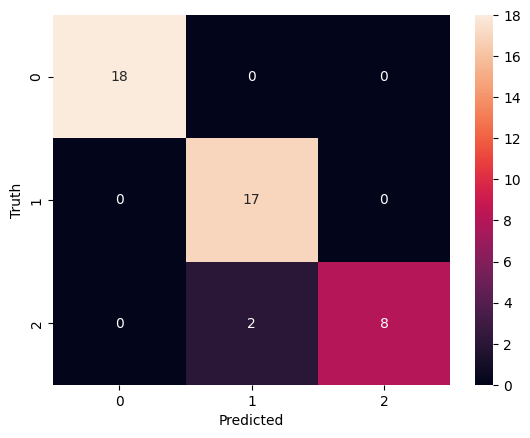

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
